In [1]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from Common.Core.Universal.NNFrameWork import NNFrameWork
from Common.Core.Universal.NNFrameworkLayers import Linear

In [2]:
x_data = torch.linspace(0, 10, steps=100).unsqueeze(1)  # 输入数据 (100, 1)
x_data_test = torch.linspace(0, 10, steps=1000).unsqueeze(1)  # 输入数据 (100, 1)
y_data = (0.1 * torch.randn_like(x_data) + 0.5 * x_data) / 4  # 添加一些噪声的目标数据

In [3]:
# 创建 TensorDataset
dataset = TensorDataset(x_data, y_data)
# 创建 DataLoader
batch_size = 1
data_iter = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [4]:
class Model0(NNFrameWork):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 10)
        self.predict_mode = True

    def forward(self, x):
        return self.linear(x)

In [9]:
class Model(NNFrameWork):
    def __init__(self):
        super().__init__()
        self.linear = Linear(1, 10)
        self.linear.predict_mode = False
        # self.linear.lr = 0.0
        # self.linear.update_mark = False
        self.linear2 = Linear(10, 1)
        # self.linear2.update_mark = True
        self.linear2.predict_mode = False
        # self.predict_mode = True

    def forward(self, x):
        return self.linear2(self.linear(x))

[{'params': <generator object Module.parameters at 0x000001778FD41070>}]
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    lr: 0.01
    maximize: False
    momentum: 0.0
    nesterov: False
    weight_decay: 0
)


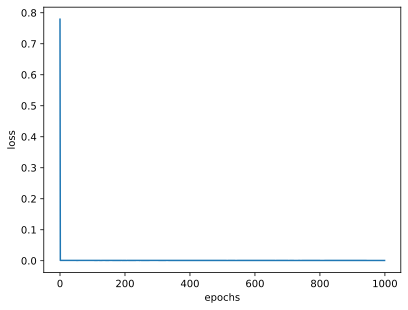

0.0007907630279920852

In [10]:
net = Model()
print(net.get_param_groups())
net.set_optimizer(lr=0.01)
net.set_criterion(nn.MSELoss())
net.set_device()
net.train_fixed(data_iter, 1000)

In [ ]:
class BaseLinear(NNFrameWork):
    def __init__(self):
        super(BaseLinear, self).__init__()
        self.linear = nn.Linear(10, 5)
        self.predict_mode = True

    def forward(self, x):
        print("method in derived forward")
        return self.linear(x)


# 创建实例并调用
test = BaseLinear()
X = torch.randn(5, 10)
test(X)

In [8]:
print(Linear(1, 10).forward)

<bound method ForwardSwitchMeta.__new__.<locals>.predict_switch.<locals>.wrapper of Linear(in_features=1, out_features=10, bias=True)>


In [9]:
linear = Linear(1, 10)
linear.predict_mode = True
linear(torch.randn(5,1))

predict_mode


tensor([[-0.0941, -0.6581, -1.0174, -0.4559,  0.9611, -0.7998,  0.2077,  0.9787,
          0.5423, -1.1494],
        [ 0.1012, -0.6489, -0.7980, -0.3269,  0.9200, -0.7899, -0.0515,  0.9238,
          0.3720, -1.0990],
        [ 0.2891, -0.6400, -0.5866, -0.2027,  0.8804, -0.7804, -0.3011,  0.8708,
          0.2081, -1.0504],
        [ 0.1488, -0.6466, -0.7443, -0.2954,  0.9100, -0.7875, -0.1149,  0.9103,
          0.3304, -1.0866],
        [ 0.8937, -0.6114,  0.0931,  0.1967,  0.7532, -0.7500, -1.1039,  0.7005,
         -0.3192, -0.8943]])

In [10]:
print(Linear.__class__)
print(Linear.forward)

<class 'Common.Core.Universal.NNFrameWork.ForwardSwitchMeta'>
<function ForwardSwitchMeta.__new__.<locals>.predict_switch.<locals>.wrapper at 0x0000024699B92A70>
